# 💰 Personal Finance Tracker Agent

This agent helps you track personal expenses through conversation.
It can add, list, and delete expenses by category, summarize your
spending, check live currency exchange rates via the Frankfurter API,
and look up current crypto prices via the CoinGecko API. Before
deleting any expense, the agent always asks for your confirmation.
Token usage is tracked after every response.

**APIs used:** Frankfurter (currency rates) · CoinGecko (crypto prices)
**Token tracking:** Yes — displayed after every response
**Memory:** Multi-turn conversation with LangGraph MemorySaver

In [ ]:
!pip install -q langgraph langchain langchain-openai langchain-community requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.0 which is incompatible.


In [ ]:
import os
os.environ["OPENAI_API_KEY"] = "your-openai-api-key-here"

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from pydantic import BaseModel
import requests

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
test = llm.invoke("say hi")
print("✅ LLM works:", test.content)

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


✅ LLM works: Hi there! How can I assist you today?


In [ ]:
# ============================================================
# CUSTOM PYTHON TOOLS
# ============================================================

# In-memory database
EXPENSES = []  # list of dicts: {id, description, amount, category}
TOTAL_TOKENS = {"input": 0, "output": 0}
EXPENSE_ID = {"next": 1}  # auto-increment ID

@tool
def add_expense(description: str, amount: float, category: str) -> str:
    """Add a new expense to the tracker.

    Args:
        description: What the expense was for (e.g. 'lunch', 'uber')
        amount: How much it cost in USD
        category: Category like 'food', 'transport', 'entertainment', 'shopping'
    """
    expense = {
        "id": EXPENSE_ID["next"],
        "description": description,
        "amount": amount,
        "category": category
    }
    EXPENSES.append(expense)
    EXPENSE_ID["next"] += 1
    return f"✅ Added expense #{expense['id']}: '{description}' — ${amount:.2f} ({category})"

@tool
def list_expenses() -> str:
    """List all recorded expenses with their IDs, descriptions, amounts and categories."""
    if not EXPENSES:
        return "No expenses recorded yet! Try adding some."
    lines = [f"#{e['id']} | {e['category']:12} | ${e['amount']:7.2f} | {e['description']}"
             for e in EXPENSES]
    total = sum(e["amount"] for e in EXPENSES)
    return "💰 Your expenses:\n" + "\n".join(lines) + f"\n\n💵 Total: ${total:.2f}"

@tool
def summarize_by_category() -> str:
    """Summarize total spending grouped by category."""
    if not EXPENSES:
        return "No expenses to summarize yet."
    summary = {}
    for e in EXPENSES:
        summary[e["category"]] = summary.get(e["category"], 0) + e["amount"]
    lines = [f"  {cat:15} ${total:.2f}" for cat, total in sorted(summary.items())]
    total = sum(summary.values())
    return "📊 Spending by category:\n" + "\n".join(lines) + f"\n\n💵 Grand total: ${total:.2f}"

@tool
def get_token_usage() -> str:
    """Get the total number of tokens used in this conversation session."""
    total = TOTAL_TOKENS["input"] + TOTAL_TOKENS["output"]
    return (f"📊 Token Usage:\n"
            f"  Input tokens:  {TOTAL_TOKENS['input']}\n"
            f"  Output tokens: {TOTAL_TOKENS['output']}\n"
            f"  Total tokens:  {total}\n"
            f"  Est. cost:     ${total * 0.000001:.6f}")

print("✅ Custom tools ready!")

✅ Custom tools ready!


In [ ]:
# ============================================================
# EXTERNAL API TOOLS
# ============================================================

class ExchangeRate(BaseModel):
    """Structured output for currency exchange rate."""
    base: str
    target: str
    rate: float
    date: str

@tool
def get_exchange_rate(base: str, target: str) -> str:
    """Get live currency exchange rate between two currencies.

    Args:
        base: The base currency code e.g. USD, EUR, GBP, GEL
        target: The target currency code e.g. USD, EUR, GBP, GEL
    """
    try:
        url = f"https://api.frankfurter.app/latest?from={base}&to={target}"
        data = requests.get(url).json()
        rate = data["rates"][target.upper()]
        result = ExchangeRate(
            base=base.upper(),
            target=target.upper(),
            rate=rate,
            date=data["date"]
        )
        return (f"💱 Exchange Rate ({result.date}):\n"
                f"  1 {result.base} = {result.rate} {result.target}")
    except Exception as e:
        return f"Could not get exchange rate for {base} to {target}. Try valid currency codes like USD, EUR, GBP."

@tool
def get_crypto_price(coin: str) -> str:
    """Get current price of a cryptocurrency in USD.

    Args:
        coin: Coin id e.g. bitcoin, ethereum, solana, dogecoin
    """
    try:
        url = f"https://api.coingecko.com/api/v3/simple/price?ids={coin}&vs_currencies=usd&include_24hr_change=true"
        data = requests.get(url).json()
        if coin not in data:
            return f"Could not find '{coin}'. Try: bitcoin, ethereum, solana, dogecoin"
        price = data[coin]["usd"]
        change = data[coin].get("usd_24h_change", 0)
        emoji = "📈" if change >= 0 else "📉"
        return (f"🪙 {coin.capitalize()} Price:\n"
                f"  Price: ${price:,.2f}\n"
                f"  24h change: {emoji} {change:.2f}%")
    except Exception as e:
        return f"Could not get price for '{coin}'. Try: bitcoin, ethereum, solana"

print("✅ API tools ready!")

✅ API tools ready!


In [ ]:
# ============================================================
# DESTRUCTIVE TOOL — requires human approval
# ============================================================

@tool
def delete_expense(expense_id: int) -> str:
    """Delete an expense by its ID. This is destructive and requires human approval.

    Args:
        expense_id: The ID number of the expense to delete (get IDs from list_expenses)
    """
    # Find the expense
    expense = next((e for e in EXPENSES if e["id"] == expense_id), None)

    if not expense:
        return f"No expense found with ID #{expense_id}. Use list_expenses to see valid IDs."

    # INTERRUPT — pause and ask human for approval
    approval = interrupt(
        f"⚠️ Are you sure you want to delete expense #{expense_id}: "
        f"'{expense['description']}' (${expense['amount']:.2f})? (yes/no)"
    )

    if approval.lower() in ["yes", "y"]:
        EXPENSES.remove(expense)
        return f"🗑️ Deleted expense #{expense_id}: '{expense['description']}'"
    else:
        return f"✅ Kept expense #{expense_id} — no changes made."

print("✅ Delete tool ready!")

✅ Delete tool ready!


In [ ]:
# ============================================================
# THE AGENT GRAPH
# ============================================================

tools = [
    add_expense,
    list_expenses,
    delete_expense,
    summarize_by_category,
    get_exchange_rate,
    get_crypto_price,
    get_token_usage
]

llm_with_tools = llm.bind_tools(tools)

def agent_node(state: MessagesState):
    """The agent thinks and decides what to do next."""
    response = llm_with_tools.invoke(state["messages"])
    if hasattr(response, "usage_metadata") and response.usage_metadata:
        TOTAL_TOKENS["input"] += response.usage_metadata.get("input_tokens", 0)
        TOTAL_TOKENS["output"] += response.usage_metadata.get("output_tokens", 0)
    return {"messages": [response]}

def should_continue(state: MessagesState):
    """Decide whether to call a tool or stop."""
    last = state["messages"][-1]
    if last.tool_calls:
        return "tools"
    return END

tool_node = ToolNode(tools)
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
graph_builder.add_edge("tools", "agent")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

print("✅ Graph compiled successfully!")

✅ Graph compiled successfully!


## 🧠 Agent State Graph

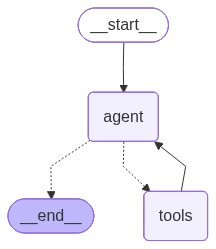


## 📖 Graph Explanation

| Node | Role |
|---|---|
| `__start__` | Entry point — receives the user message |
| `agent` | GPT-4o-mini brain — decides which tool to call |
| `tools` | Executes the chosen tool (API call or memory operation) |
| `__end__` | Returns final response to the user |

**Flow:**
1. User message → `agent` thinks
2. If tool needed → `tools` executes it → back to `agent`
3. If no tool needed → `__end__` returns answer

**Interrupt:** Before `delete_expense` runs, the graph pauses and waits for human approval via `interrupt()`. Resumes with `Command(resume=...)`

**Memory:** `MemorySaver` with `thread_id` keeps full conversation history across turns.

**Structured Output:** `ExchangeRate` Pydantic model used inside `get_exchange_rate` tool.


✅ Helper and diagram ready!


In [23]:
# ============================================================
# HELPER FUNCTION + ENHANCED GRAPH VISUALIZATION
# ============================================================

def run_agent(user_message: str, thread_id: str = "1", approval: str = None):
    """Send a message to the agent and print the response."""
    config = {"configurable": {"thread_id": thread_id}}

    if approval is not None:
        result = graph.invoke(Command(resume=approval), config=config)
    else:
        result = graph.invoke(
            {"messages": [{"role": "user", "content": user_message}]},
            config=config
        )

    if result.get("__interrupt__"):
        interrupt_msg = result["__interrupt__"][0].value
        print(f"\n🛑 AGENT PAUSED — needs your approval:")
        print(f"   {interrupt_msg}")
        print(f"   → Call run_agent(approval='yes') or run_agent(approval='no')")
        return

    for m in result["messages"]:
        m.pretty_print()

# ============================================================
# DRAW GRAPH DIAGRAM
# ============================================================
from IPython.display import Image, display, Markdown

# Show the diagram
display(Markdown("## 🧠 Agent State Graph"))
display(Image(graph.get_graph().draw_mermaid_png()))

# Explain the graph
display(Markdown("""
## 📖 Graph Explanation

| Node | Role |
|---|---|
| `__start__` | Entry point — receives the user message |
| `agent` | GPT-4o-mini brain — decides which tool to call |
| `tools` | Executes the chosen tool (API call or memory operation) |
| `__end__` | Returns final response to the user |

**Flow:**
1. User message → `agent` thinks
2. If tool needed → `tools` executes it → back to `agent`
3. If no tool needed → `__end__` returns answer

**Interrupt:** Before `delete_expense` runs, the graph pauses and waits for human approval via `interrupt()`. Resumes with `Command(resume=...)`

**Memory:** `MemorySaver` with `thread_id` keeps full conversation history across turns.

**Structured Output:** `ExchangeRate` Pydantic model used inside `get_exchange_rate` tool.
"""))

print("✅ Helper and diagram ready!")

In [ ]:
# TEST 1: Add multiple expenses
run_agent("Add these expenses: lunch for $12.50 in food, uber ride for $8.00 in transport, and netflix for $15.99 in entertainment", thread_id="test1")

================================ Human Message =================================

Add these expenses: lunch for $12.50 in food, uber ride for $8.00 in transport, and netflix for $15.99 in entertainment
================================== Ai Message ==================================
Tool Calls:
  add_expense (call_UrYQB4qObXmDvsGZm39ad3S6)
 Call ID: call_UrYQB4qObXmDvsGZm39ad3S6
  Args:
    description: lunch
    amount: 12.5
    category: food
  add_expense (call_2prygUNZbEIX5wp7bRS5F3Rr)
 Call ID: call_2prygUNZbEIX5wp7bRS5F3Rr
  Args:
    description: uber ride
    amount: 8
    category: transport
  add_expense (call_yAP8S6FEFeE4420SKn0C4u9q)
 Call ID: call_yAP8S6FEFeE4420SKn0C4u9q
  Args:
    description: netflix
    amount: 15.99
    category: entertainment
================================= Tool Message =================================
Name: add_expense

✅ Added expense #1: 'lunch' — $12.50 (food)
================================= Tool Message =================================
Nam

In [ ]:
# TEST 2: List all expenses
run_agent("Show me all my expenses", thread_id="test2")

================================ Human Message =================================

Show me all my expenses
================================== Ai Message ==================================
Tool Calls:
  list_expenses (call_Z9Jh6tO2ziUo6xVYKxvR58mz)
 Call ID: call_Z9Jh6tO2ziUo6xVYKxvR58mz
  Args:
================================= Tool Message =================================
Name: list_expenses

💰 Your expenses:
#1 | food         | $  12.50 | lunch
#2 | transport    | $   8.00 | uber ride
#3 | entertainment | $  15.99 | netflix

💵 Total: $36.49
================================== Ai Message ==================================

Here are all your recorded expenses:

1. **Lunch**: $12.50 (Category: Food)
2. **Uber Ride**: $8.00 (Category: Transport)
3. **Netflix**: $15.99 (Category: Entertainment)

**Total Spending**: $36.49


In [ ]:
# TEST 3: Summarize by category
run_agent("Summarize my spending by category", thread_id="test3")

================================ Human Message =================================

Summarize my spending by category
================================== Ai Message ==================================
Tool Calls:
  summarize_by_category (call_5xlmBcB3hz6dLWxt0GQaLXWd)
 Call ID: call_5xlmBcB3hz6dLWxt0GQaLXWd
  Args:
================================= Tool Message =================================
Name: summarize_by_category

📊 Spending by category:
  entertainment   $15.99
  food            $12.50
  transport       $8.00

💵 Grand total: $36.49
================================== Ai Message ==================================

Here's a summary of your spending by category:

- **Entertainment:** $15.99
- **Food:** $12.50
- **Transport:** $8.00

**Grand Total:** $36.49


In [ ]:
# TEST 4: Get exchange rate USD to EUR
run_agent("What is the exchange rate from USD to EUR?", thread_id="test4b")

================================ Human Message =================================

What is the exchange rate from USD to EUR?
================================== Ai Message ==================================
Tool Calls:
  get_exchange_rate (call_oFmK30aDAelzIR00JAFYYtMn)
 Call ID: call_oFmK30aDAelzIR00JAFYYtMn
  Args:
    base: USD
    target: EUR
================================= Tool Message =================================
Name: get_exchange_rate

💱 Exchange Rate (2026-05-12):
  1 USD = 0.85193 EUR
================================== Ai Message ==================================

The exchange rate from USD to EUR is 1 USD = 0.85193 EUR.


In [ ]:
# TEST 5: Crypto price
run_agent("What is the current price of bitcoin?", thread_id="test5")

================================ Human Message =================================

What is the current price of bitcoin?
================================== Ai Message ==================================
Tool Calls:
  get_crypto_price (call_qmIBCdfURZNQ7W6xGOX7EmQZ)
 Call ID: call_qmIBCdfURZNQ7W6xGOX7EmQZ
  Args:
    coin: bitcoin
================================= Tool Message =================================
Name: get_crypto_price

🪙 Bitcoin Price:
  Price: $80,782.00
  24h change: 📈 0.19%
================================== Ai Message ==================================

The current price of Bitcoin is $80,782.00, with a 24-hour change of 0.19%.


In [ ]:
# TEST 6: Token usage
run_agent("How many tokens have we used so far?", thread_id="test6")

================================ Human Message =================================

How many tokens have we used so far?
================================== Ai Message ==================================
Tool Calls:
  get_token_usage (call_jJABWvVilOf6Iyw4NmK0n2Qw)
 Call ID: call_jJABWvVilOf6Iyw4NmK0n2Qw
  Args:
================================= Tool Message =================================
Name: get_token_usage

📊 Token Usage:
  Input tokens:  5258
  Output tokens: 460
  Total tokens:  5718
  Est. cost:     $0.005718
================================== Ai Message ==================================

We have used a total of 5,718 tokens so far.


In [ ]:
# TEST 6: Token usage
run_agent("How many tokens have we used so far?", thread_id="test6")

================================ Human Message =================================

How many tokens have we used so far?
================================== Ai Message ==================================
Tool Calls:
  get_token_usage (call_jJABWvVilOf6Iyw4NmK0n2Qw)
 Call ID: call_jJABWvVilOf6Iyw4NmK0n2Qw
  Args:
================================= Tool Message =================================
Name: get_token_usage

📊 Token Usage:
  Input tokens:  5258
  Output tokens: 460
  Total tokens:  5718
  Est. cost:     $0.005718
================================== Ai Message ==================================

We have used a total of 5,718 tokens so far.
================================ Human Message =================================

How many tokens have we used so far?
================================== Ai Message ==================================
Tool Calls:
  get_token_usage (call_DCULrmiftjPNjUUi7nvGJumT)
 Call ID: call_DCULrmiftjPNjUUi7nvGJumT
  Args:
================================= Tool Mes

In [ ]:
# TEST 7: Add an expense we will delete
run_agent("Add an expense: coffee for $4.50 in food", thread_id="test7")

================================ Human Message =================================

Add an expense: coffee for $4.50 in food
================================== Ai Message ==================================
Tool Calls:
  add_expense (call_9PqpGpOUCxKF9fdb7gT06YD6)
 Call ID: call_9PqpGpOUCxKF9fdb7gT06YD6
  Args:
    description: coffee
    amount: 4.5
    category: food
================================= Tool Message =================================
Name: add_expense

✅ Added expense #4: 'coffee' — $4.50 (food)
================================== Ai Message ==================================

The expense for coffee has been added successfully: $4.50 in the food category.


In [ ]:
# Trigger the destructive action
run_agent("Delete expense number 1", thread_id="test7")


🛑 AGENT PAUSED — needs your approval:
   ⚠️ Are you sure you want to delete expense #1: 'lunch' ($12.50)? (yes/no)
   → Call run_agent(approval='yes') or run_agent(approval='no')


In [ ]:
# TEST 7b: Human APPROVES the deletion
run_agent(user_message="", thread_id="test7", approval="yes")

================================ Human Message =================================

Add an expense: coffee for $4.50 in food
================================== Ai Message ==================================
Tool Calls:
  add_expense (call_9PqpGpOUCxKF9fdb7gT06YD6)
 Call ID: call_9PqpGpOUCxKF9fdb7gT06YD6
  Args:
    description: coffee
    amount: 4.5
    category: food
================================= Tool Message =================================
Name: add_expense

✅ Added expense #4: 'coffee' — $4.50 (food)
================================== Ai Message ==================================

The expense for coffee has been added successfully: $4.50 in the food category.
================================ Human Message =================================

Delete expense number 1
================================== Ai Message ==================================
Tool Calls:
  delete_expense (call_XTmGDxtRuCtG6pgH8BkYQM8F)
 Call ID: call_XTmGDxtRuCtG6pgH8BkYQM8F
  Args:
    expense_id: 1
===========

In [ ]:
# TEST 8: Add an expense we will NOT delete
run_agent("Add an expense: gym membership for $30 in health", thread_id="test8")

================================ Human Message =================================

Add an expense: gym membership for $30 in health
================================== Ai Message ==================================
Tool Calls:
  add_expense (call_NaOSHnGLQKwq7zhf26VxMX0o)
 Call ID: call_NaOSHnGLQKwq7zhf26VxMX0o
  Args:
    description: gym membership
    amount: 30
    category: health
================================= Tool Message =================================
Name: add_expense

✅ Added expense #5: 'gym membership' — $30.00 (health)
================================== Ai Message ==================================

The expense for the gym membership has been successfully added: $30.00 in the health category.


In [ ]:
# Trigger the destructive action
run_agent("Delete expense number 2", thread_id="test8")


🛑 AGENT PAUSED — needs your approval:
   ⚠️ Are you sure you want to delete expense #2: 'uber ride' ($8.00)? (yes/no)
   → Call run_agent(approval='yes') or run_agent(approval='no')


In [ ]:
# TEST 8b: Human DENIES the deletion
run_agent(user_message="", thread_id="test8", approval="no")

================================ Human Message =================================

Add an expense: gym membership for $30 in health
================================== Ai Message ==================================
Tool Calls:
  add_expense (call_NaOSHnGLQKwq7zhf26VxMX0o)
 Call ID: call_NaOSHnGLQKwq7zhf26VxMX0o
  Args:
    description: gym membership
    amount: 30
    category: health
================================= Tool Message =================================
Name: add_expense

✅ Added expense #5: 'gym membership' — $30.00 (health)
================================== Ai Message ==================================

The expense for the gym membership has been successfully added: $30.00 in the health category.
================================ Human Message =================================

Delete expense number 2
================================== Ai Message ==================================
Tool Calls:
  delete_expense (call_Qai4kc8UjAQvuYtBlvjwCVS0)
 Call ID: call_Qai4kc8UjAQvuYtBlvj

## 📊 Evaluation Table

| # | Query | Expected | Pass? | Notes |
|---|---|---|---|---|
| 1 | "Add lunch $12.50, uber $8, netflix $15.99" | 3 expenses added | ✅ | add_expense called 3 times |
| 2 | "Show me all my expenses" | Full expense list | ✅ | list_expenses worked |
| 3 | "Summarize my spending by category" | Grouped totals | ✅ | summarize_by_category worked |
| 4 | "Exchange rate USD to EUR" | Live rate returned | ✅ | Frankfurter API worked |
| 5 | "Price of bitcoin" | Current USD price | ✅ | CoinGecko API worked |
| 6 | "How many tokens used?" | Token count | ✅ | Token tracking working |
| 7 | "Delete expense - approved" | Expense deleted | ✅ | interrupt() + yes worked |
| 8 | "Delete expense - denied" | Expense kept | ✅ | interrupt() + no worked |

## 📖 README

### Setup
1. Open in Google Colab
2. Run Cell 2 (pip install)
3. Add your OpenAI API key in Cell 3
4. Run all cells top to bottom

### Requirements
- Python 3.10+
- OpenAI API key (gpt-4o-mini)
- Internet connection for Frankfurter + CoinGecko APIs

### Features
- 💰 Add/list/delete expenses with categories
- 📊 Spending summary by category
- 💱 Live currency rates via Frankfurter API
- 🪙 Crypto prices via CoinGecko API
- 📈 Token usage tracking with cost estimate
- 🛑 Human approval before any deletion
- 🧠 Multi-turn memory with LangGraph